[![preview notebook](https://img.shields.io/static/v1?label=render%20on&logo=github&color=87ce3e&message=GitHub)](https://github.com/open-atmos/PySDM/blob/main/examples/PySDM_examples/Luettmer_homogeneous_freezing/fig_4_5_6_S3_S4.ipynb)
[![launch on mybinder.org](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/open-atmos/PySDM.git/main?urlpath=lab/tree/examples/PySDM_examples/Luettmer_homogeneous_freezing/fig_4_5_6_S3_S4.ipynb)
[![launch on Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-atmos/PySDM/blob/main/examples/PySDM_examples/Luettmer_homogeneous_freezing/fig_4_5_6_S3_S4.ipynb)

Fig. 4, 5, 6 and Supplement Fig. 3 and 4

In [1]:
import os, sys
os.environ['NUMBA_THREADING_LAYER'] = 'workqueue'  # PySDM & PyMPDATA don't work with TBB; OpenMP has extra dependencies on macOS
if 'google.colab' in sys.modules:
    !pip --quiet install open-atmos-jupyter-utils
    from open_atmos_jupyter_utils import pip_install_on_colab
    pip_install_on_colab('PySDM-examples', 'PySDM')

In [39]:
import numpy as np
from PySDM.physics.constants import si
from PySDM_examples.Luettmer_et_al_2026.commons import run_simulations, hom_pure_droplet_freezing_backend, hom_pure_droplet_freezing_standard_setup
from PySDM_examples.Luettmer_et_al_2026 import plot
from open_atmos_jupyter_utils import show_plot
from matplotlib import pyplot

In [3]:
# General settings
hom_freezing_types     = [  "KoopMurray2016", "KoopMurray2016_DWA" ]
hom_freezing_labels    = [      "JHOM-T",             "JHOM-DWA"]
number_of_nsd = (1e2, 1e3, 1e4) if 'CI' not in os.environ else (1e1, 2e1)
vertical_updrafts = np.geomspace(0.2,10,num=9 if 'CI' not in os.environ else 2) * si.meter / si.second
number_concentrations = np.geomspace(100, 10000, num=10 if 'CI' not in os.environ else 2) / si.cm ** 3

backends = hom_pure_droplet_freezing_backend()
standard = hom_pure_droplet_freezing_standard_setup()


In [4]:
# Simulations for n_sd ensemble with deposition
nsd_ensemble_deposition = {}
nsd_ensemble_deposition["ens_variable"] = number_of_nsd
nsd_ensemble_deposition["ens_variable_name"] = "n_sd"
nsd_ensemble_deposition["hom_freezing_types"] = hom_freezing_types
nsd_ensemble_deposition["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    nsd_ensemble_deposition[hom_freezing_type] = []
    for n_sd in number_of_nsd:
        setting_dict = {
            **standard,
            "n_sd": int(n_sd),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "number_of_ensemble_runs": 5 if 'CI' not in os.environ else 1,
            "deposition_enable": True,
            }
        nsd_ensemble_deposition[hom_freezing_type].append( run_simulations(setting_dict) )

In [5]:
# Simulations for updraft histogram with deposition
updraft_ensemble_deposition = {}
updraft_ensemble_deposition["ens_variable"] = vertical_updrafts
updraft_ensemble_deposition["ens_variable_name"] = "w_updraft"
updraft_ensemble_deposition["hom_freezing_types"] = hom_freezing_types
updraft_ensemble_deposition["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    updraft_ensemble_deposition[hom_freezing_type] = []
    for updraft in vertical_updrafts:
        setting_dict = {
            **standard,
            "w_updraft": updraft  * si.meter / si.second,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "number_of_ensemble_runs": 1,
            }

        updraft_ensemble_deposition[hom_freezing_type].append( run_simulations(setting_dict) )

In [6]:
# Simulations for CCN concentration histogram
ccn_ensemble_deposition = {}
ccn_ensemble_deposition["ens_variable"] = number_concentrations
ccn_ensemble_deposition["ens_variable_name"] = "n_ccn"
ccn_ensemble_deposition["hom_freezing_types"] = hom_freezing_types
ccn_ensemble_deposition["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    ccn_ensemble_deposition[hom_freezing_type] = []
    for n_dv in number_concentrations:
        setting_dict = {
            **standard,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "n_ccn": n_dv,
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "dz": 0.5 * si.meter,
        }
        ccn_ensemble_deposition[hom_freezing_type].append(run_simulations(setting_dict))

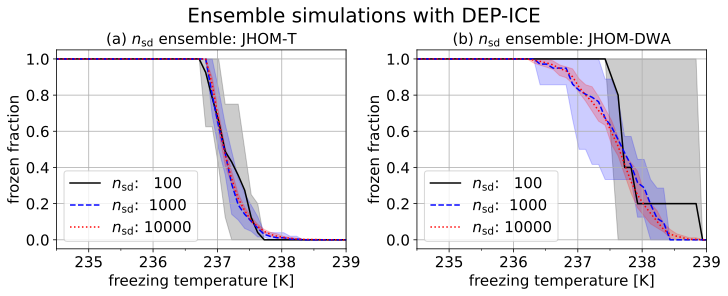

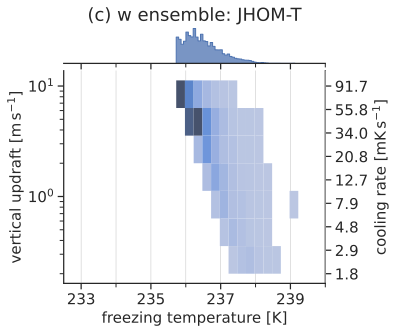

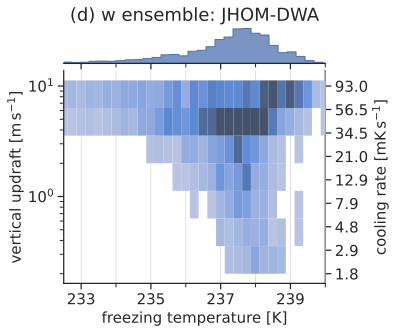

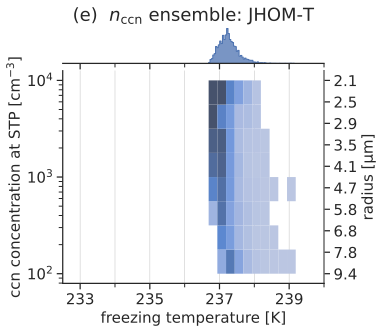

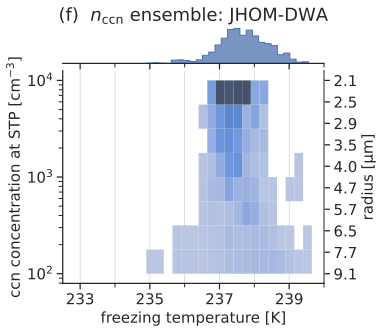

In [7]:
# Plot Figure 4
fig_name = "fig4_"
fig, axs = pyplot.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
fig.suptitle("Ensemble simulations with DEP-ICE", fontsize=20)

axs = axs.ravel()

axs[0] = plot.plot_freezing_temperatures_histogram_allinone(axs[0], nsd_ensemble_deposition["KoopMurray2016"], title = r"(a) $n_\text{sd}$ ensemble: JHOM-T", lloc="lower left")
axs[1] = plot.plot_freezing_temperatures_histogram_allinone(axs[1], nsd_ensemble_deposition["KoopMurray2016_DWA"], title = r"(b) $n_\text{sd}$ ensemble: JHOM-DWA", lloc="lower left")
show_plot(fig_name+"ab")

plot.plot_freezing_temperatures_2d_histogram_seaborn(updraft_ensemble_deposition, "KoopMurray2016", title = "(c) w ensemble: JHOM-T")
show_plot(fig_name+"c")

plot.plot_freezing_temperatures_2d_histogram_seaborn(updraft_ensemble_deposition, "KoopMurray2016_DWA", title = "(d) w ensemble: JHOM-DWA")
show_plot(fig_name+"d")

plot.plot_freezing_temperatures_2d_histogram_seaborn(ccn_ensemble_deposition, "KoopMurray2016", title = r"(e)  $n_\text{ccn}$ ensemble: JHOM-T")
show_plot(fig_name+"e")

plot.plot_freezing_temperatures_2d_histogram_seaborn(ccn_ensemble_deposition, "KoopMurray2016_DWA", title = r"(f)  $n_\text{ccn}$ ensemble: JHOM-DWA")
show_plot(fig_name+"f")

In [26]:
# General settings for simulations with log-normal distribution
hom_freezing_types     = [  "KoopMurray2016" ]

number_of_nsd = (1e2, 1e3, 1e4)
vertical_updrafts = np.geomspace(0.2,10,num=9) * si.meter / si.second
number_concentrations = np.geomspace(100, 10000, num=10) / si.cm ** 3
sigmas = np.linspace( 1.5, 2., num=6)

backends = hom_pure_droplet_freezing_backend()
standard_sig = hom_pure_droplet_freezing_standard_setup()
standard_sig["type_droplet_distribution"] = "lognormal"
standard_sig["sigma_droplet_distribution"] = 2.0
standard_sig["r_ccn"] =  0.05e-6
standard_sig["n_sd"] =  int(1e4 if 'CI' not in os.environ else 1e1)

hom_freezing_labels  = [ r"JHOM-T: $\sigma=$"+str(standard_sig["sigma_droplet_distribution"]) ]

In [27]:
# Simulations for n_sd ensemble with deposition
nsd_ensemble_deposition_sig = {}
nsd_ensemble_deposition_sig["ens_variable"] = number_of_nsd
nsd_ensemble_deposition_sig["ens_variable_name"] = "n_sd"
nsd_ensemble_deposition_sig["hom_freezing_types"] = hom_freezing_types
nsd_ensemble_deposition_sig["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    nsd_ensemble_deposition_sig[hom_freezing_type] = []
    for n_sd in number_of_nsd:
        setting_dict = {
            **standard_sig,
            "n_sd": int(n_sd),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "number_of_ensemble_runs": 5 if 'CI' not in os.environ else 1,
            "deposition_enable": True,
            }
        nsd_ensemble_deposition_sig[hom_freezing_type].append( run_simulations(setting_dict) )

In [10]:
#  Simulations for n_sd ensemble without deposition
nsd_ensemble_no_deposition_sig = {}
nsd_ensemble_no_deposition_sig["ens_variable"] = number_of_nsd
nsd_ensemble_no_deposition_sig["ens_variable_name"] = "n_sd"
nsd_ensemble_no_deposition_sig["hom_freezing_types"] = hom_freezing_types

for hom_freezing_type in hom_freezing_types:
    nsd_ensemble_no_deposition_sig[hom_freezing_type] = []
    for n_sd in number_of_nsd:
        setting_dict = {
            **standard_sig,
            "n_sd": int(n_sd),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "number_of_ensemble_runs": 5 if 'CI' not in os.environ else 1,
            "deposition_enable": False,
        }
        nsd_ensemble_no_deposition_sig[hom_freezing_type].append(run_simulations(setting_dict))

In [11]:
# Updraft ensemble simulations without deposition
updraft_ensemble_no_deposition_sig = {}
updraft_ensemble_no_deposition_sig["ens_variable"] = vertical_updrafts
updraft_ensemble_no_deposition_sig["ens_variable_name"] = "w_updraft"
updraft_ensemble_no_deposition_sig["hom_freezing_types"] = hom_freezing_types

for hom_freezing_type in hom_freezing_types:
    updraft_ensemble_no_deposition_sig[hom_freezing_type] = []
    for updraft in vertical_updrafts:
        setting_dict = {
            **standard_sig,
            "w_updraft": updraft,
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "deposition_enable": False,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            }
        updraft_ensemble_no_deposition_sig[hom_freezing_type].append( run_simulations(setting_dict) )

In [12]:
# Simulations for updraft histogram with deposition
updraft_ensemble_deposition_sig = {}
updraft_ensemble_deposition_sig["ens_variable"] = vertical_updrafts
updraft_ensemble_deposition_sig["ens_variable_name"] = "w_updraft"
updraft_ensemble_deposition_sig["hom_freezing_types"] = hom_freezing_types
updraft_ensemble_deposition_sig["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    updraft_ensemble_deposition_sig[hom_freezing_type] = []
    for updraft in vertical_updrafts:
        setting_dict = {
            **standard_sig,
            "w_updraft": updraft  * si.meter / si.second,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "number_of_ensemble_runs": 1,
            }

        updraft_ensemble_deposition_sig[hom_freezing_type].append( run_simulations(setting_dict) )

In [21]:
# Simulations for CCN concentration histogram
ccn_ensemble_no_deposition_sig = {}
ccn_ensemble_no_deposition_sig["ens_variable"] = number_concentrations
ccn_ensemble_no_deposition_sig["ens_variable_name"] = "n_ccn"
ccn_ensemble_no_deposition_sig["hom_freezing_types"] = hom_freezing_types

for hom_freezing_type in hom_freezing_types:
    ccn_ensemble_no_deposition_sig[hom_freezing_type] = []
    for n_ccn in number_concentrations:
        setting_dict = {
            **standard_sig,
            "n_ccn": n_ccn,
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "deposition_enable": False,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
        }
        ccn_ensemble_no_deposition_sig[hom_freezing_type].append(run_simulations(setting_dict))

In [29]:
# Simulations for CCN concentration histogram
ccn_ensemble_deposition_sig = {}
ccn_ensemble_deposition_sig["ens_variable"] = number_concentrations
ccn_ensemble_deposition_sig["ens_variable_name"] = "n_ccn"
ccn_ensemble_deposition_sig["hom_freezing_types"] = hom_freezing_types
ccn_ensemble_deposition_sig["hom_freezing_labels"] = hom_freezing_labels

for hom_freezing_type in hom_freezing_types:
    ccn_ensemble_deposition_sig[hom_freezing_type] = []
    for n_dv in number_concentrations:
        setting_dict = {
            **standard_sig,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "n_ccn": n_dv,
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "dz": 0.5 * si.meter,
        }
        ccn_ensemble_deposition_sig[hom_freezing_type].append(run_simulations(setting_dict))

In [15]:
# Simulations for size distribution sigma histogram
sig_ensemble_deposition_sig = {}
sig_ensemble_deposition_sig["ens_variable"] = sigmas
sig_ensemble_deposition_sig["ens_variable_name"] = "sig"
sig_ensemble_deposition_sig["hom_freezing_types"] = hom_freezing_types
sig_ensemble_deposition_sig["hom_freezing_labels"] =  [ r"JHOM-T" ]

for hom_freezing_type in hom_freezing_types:
    sig_ensemble_deposition_sig[hom_freezing_type] = []
    for sig in sigmas:
        setting_dict = {
            **standard_sig,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "sigma_droplet_distribution": sig,
        }
        sig_ensemble_deposition_sig[hom_freezing_type].append(run_simulations(setting_dict))

In [16]:
# Simulations for size distribution sigma histogram
sig_ensemble_no_deposition_sig = {}
sig_ensemble_no_deposition_sig["ens_variable"] = sigmas
sig_ensemble_no_deposition_sig["ens_variable_name"] = "sig"
sig_ensemble_no_deposition_sig["hom_freezing_types"] = hom_freezing_types
sig_ensemble_no_deposition_sig["hom_freezing_labels"] =  [ r"JHOM-T" ]

for hom_freezing_type in hom_freezing_types:
    sig_ensemble_no_deposition_sig[hom_freezing_type] = []
    for sig in sigmas:
        setting_dict = {
            **standard_sig,
            "n_sd": int(1e4 if 'CI' not in os.environ else 1e1),
            "backend": backends[hom_freezing_type],
            "hom_freezing": hom_freezing_type,
            "sigma_droplet_distribution": sig,
            "deposition_enable": False,
        }
        sig_ensemble_no_deposition_sig[hom_freezing_type].append(run_simulations(setting_dict))

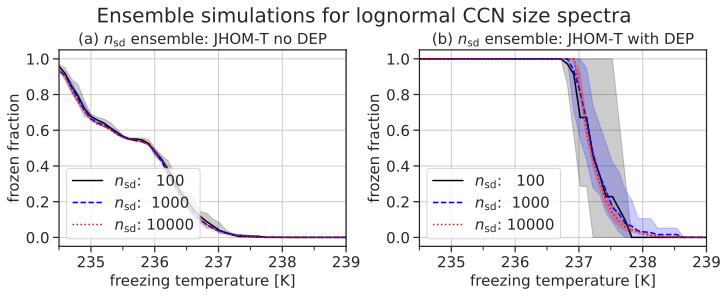

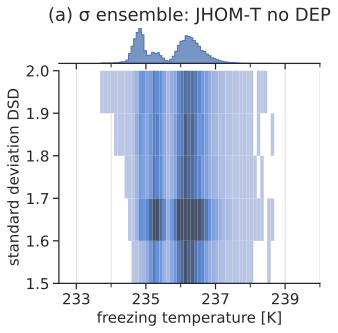

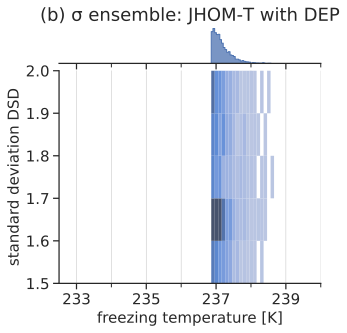

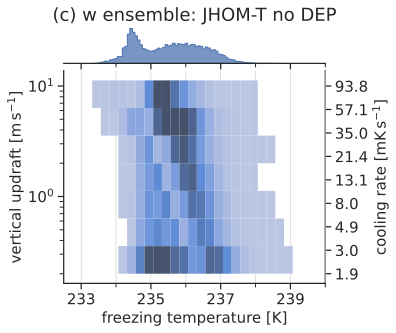

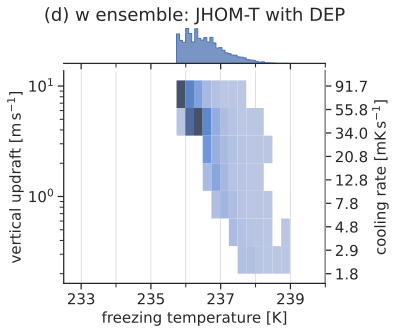

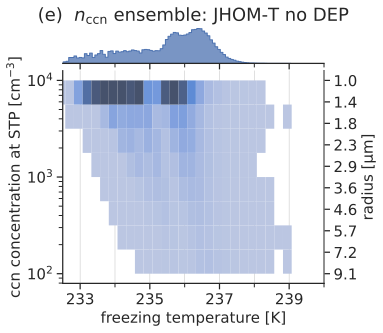

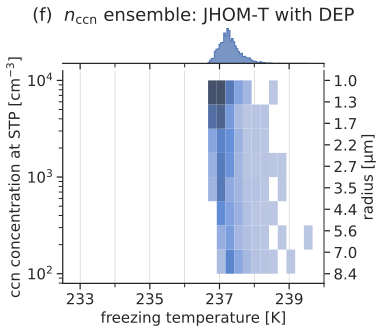

In [44]:
# Plot Figure 6 and Sup 3
fig_name = "fig_sup_3"
fig, axs = pyplot.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
fig.suptitle("Ensemble simulations for lognormal CCN size spectra", fontsize=20)

axs = axs.ravel()
axs[0] = plot.plot_freezing_temperatures_histogram_allinone(axs[0], nsd_ensemble_no_deposition_sig["KoopMurray2016"], title = r"(a) $n_\text{sd}$ ensemble: JHOM-T no DEP", lloc="lower left")
axs[1] = plot.plot_freezing_temperatures_histogram_allinone(axs[1], nsd_ensemble_deposition_sig["KoopMurray2016"], title = r"(b) $n_\text{sd}$ ensemble: JHOM-T with DEP", lloc="lower left")
show_plot(fig_name)


fig_name = "fig6_"

plot.plot_freezing_temperatures_2d_histogram_seaborn(sig_ensemble_no_deposition_sig, "KoopMurray2016", title = r"(a) $\mathrm{\sigma}$ ensemble: JHOM-T no DEP")
show_plot(fig_name+"a")

plot.plot_freezing_temperatures_2d_histogram_seaborn(sig_ensemble_deposition_sig, "KoopMurray2016", title = r"(b) $\mathrm{\sigma}$ ensemble: JHOM-T with DEP")
show_plot(fig_name+"b")

plot.plot_freezing_temperatures_2d_histogram_seaborn(updraft_ensemble_no_deposition_sig, "KoopMurray2016", title = "(c) w ensemble: JHOM-T no DEP")
show_plot(fig_name+"c")

plot.plot_freezing_temperatures_2d_histogram_seaborn(updraft_ensemble_deposition_sig, "KoopMurray2016", title = "(d) w ensemble: JHOM-T with DEP")
show_plot(fig_name+"d")

plot.plot_freezing_temperatures_2d_histogram_seaborn(ccn_ensemble_no_deposition_sig, "KoopMurray2016", title = r"(e)  $n_\text{ccn}$ ensemble: JHOM-T no DEP")
show_plot(fig_name+"e")

plot.plot_freezing_temperatures_2d_histogram_seaborn(ccn_ensemble_deposition_sig, "KoopMurray2016", title = r"(f)  $n_\text{ccn}$ ensemble: JHOM-T with DEP")
show_plot(fig_name+"f")

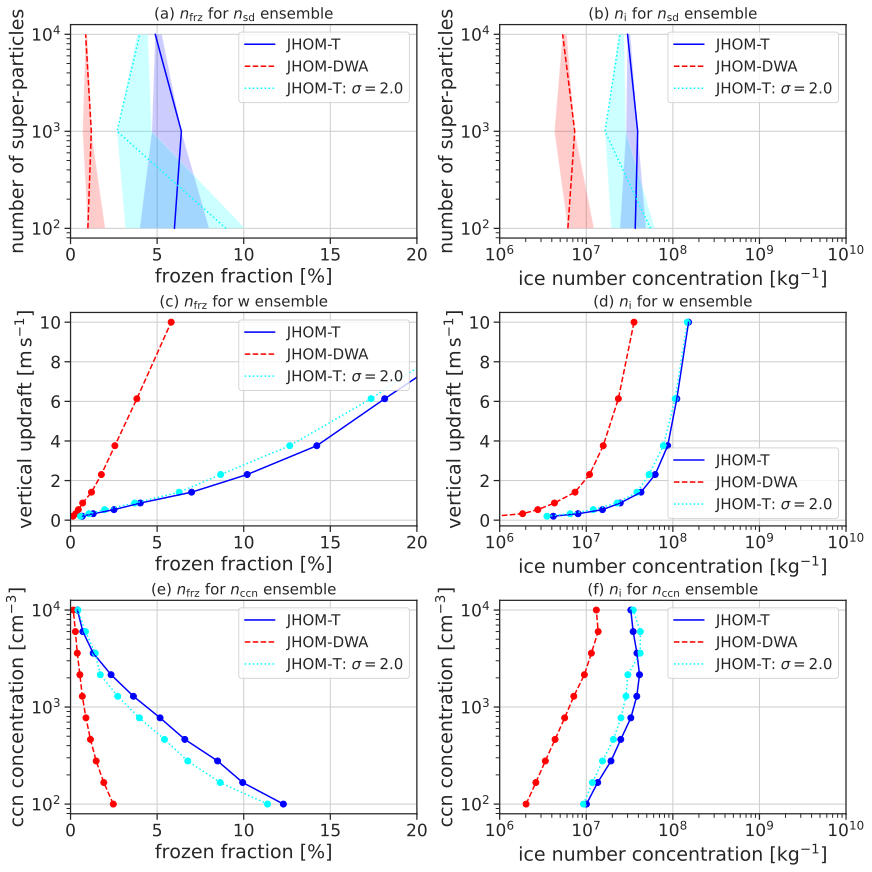

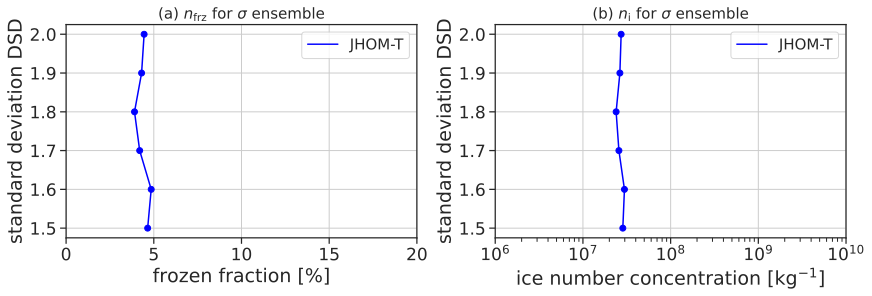

In [32]:
# Plot figure 5
fig_name = "fig5"
fig, axs = pyplot.subplots(3, 2, figsize=(12, 12), constrained_layout=True)
plot_ensembles = [ [nsd_ensemble_deposition,nsd_ensemble_deposition_sig],
                   [updraft_ensemble_deposition, updraft_ensemble_deposition_sig],
                   [ccn_ensemble_deposition,ccn_ensemble_deposition_sig],
                   ]
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
axs = axs.ravel()
ix = 0
for plot_ensemble in plot_ensembles:

    axs[ix] = plot.plot_ensemble_bulk(axs[ix],plot_ensemble, "freezing_fraction", title_add=panel_labels[ix])
    ix += 1
    axs[ix] = plot.plot_ensemble_bulk(axs[ix],plot_ensemble, "ni", title_add=panel_labels[ix])
    ix += 1

show_plot(fig_name)

fig_name = "fig_sup5"
fig, axs = pyplot.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

plot_ensembles = [[sig_ensemble_deposition_sig],]

panel_labels = ["(a)", "(b)"]
axs = axs.ravel()
ix = 0
ix = 0
for plot_ensemble in plot_ensembles:

    axs[ix] = plot.plot_ensemble_bulk(axs[ix],plot_ensemble, "freezing_fraction", title_add=panel_labels[ix])
    ix += 1
    axs[ix] = plot.plot_ensemble_bulk(axs[ix],plot_ensemble, "ni", title_add=panel_labels[ix])
    ix += 1

show_plot(fig_name)


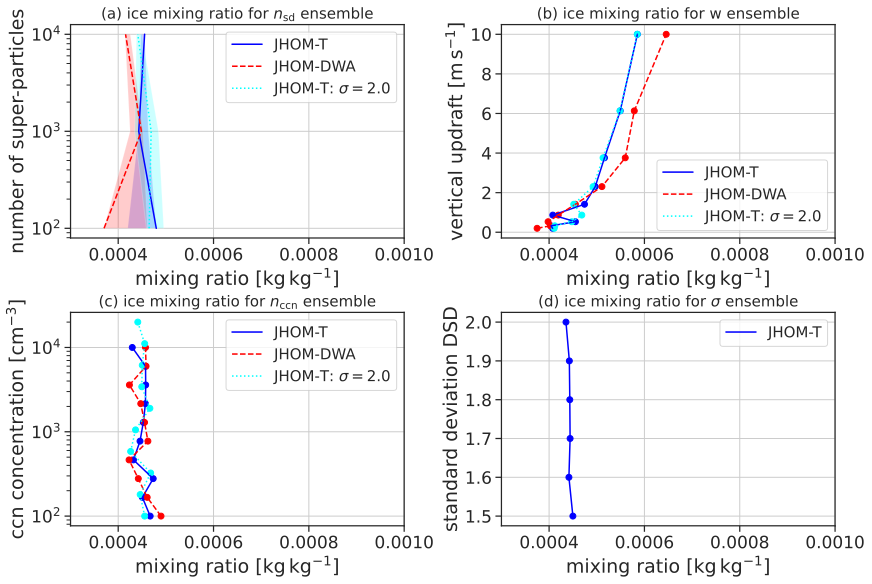

In [19]:
fig_name = "fig_sup_4"
fig, axs = pyplot.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

plot_ensembles = [ [nsd_ensemble_deposition,nsd_ensemble_deposition_sig],
                   [updraft_ensemble_deposition, updraft_ensemble_deposition_sig],
                   [ccn_ensemble_deposition,ccn_ensemble_deposition_sig],
                   [sig_ensemble_deposition_sig],
                   ]
panel_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]
axs = axs.ravel()
ix = 0
for plot_ensemble in plot_ensembles:

    axs[ix] = plot.plot_ensemble_bulk(axs[ix],plot_ensemble, "IWC", title_add=panel_labels[ix])
    ix += 1
show_plot(fig_name)